In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

## Provided Functions


In [3]:
def read_data() -> pd.DataFrame:
    """
    This helper function reads in a `csv` file based on the given `dataset_number`.

    Returns:
        pd.DataFrame: A `pandas` DataFrame used in the assignment.
    """
    dataset = pd.read_csv(f"spending_data.csv")
    return dataset

# Plotting sample


Sample Mean: 15.19, Sample Std Dev: 4.82


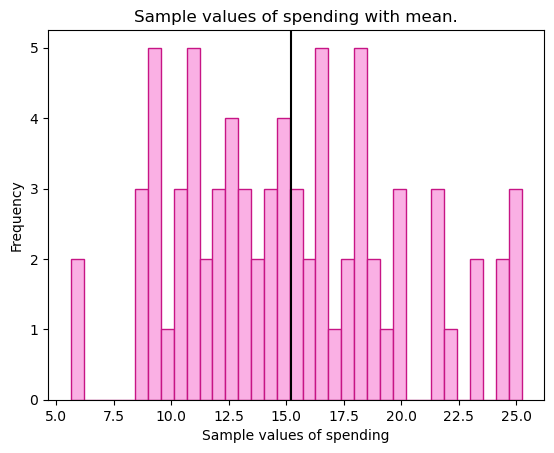

In [16]:
def sampling(dataset, n: int , random_state: int, column: str):
    """
    This function takes a random sample of size n from the given dataset.

    Args:
        dataset: The data to sample from.
        n: The sample size.
        random_state: The random seed to use for reproducibility.
        column: The name of the column to use.

    Returns:
        The random sample with the given sample size.
    """
    np.random.seed(random_state)

    sample = dataset[column].sample(n = n,random_state = random_state)
    return sample

dataset = read_data()

sample1 = sampling(dataset, 75, 12538316, "spending")

sample_mean = np.mean(sample1)
sample_std_dev = np.std(sample1)

print(f"Sample Mean: {sample_mean:.2f}, Sample Std Dev: {sample_std_dev:.2f}")

def plot_sample_histogram(sample , mean: float) -> None:
    """
    This function generates a histogram of the given sample and highlights the mean as a vertical line.

    Args:
        sample: The sample to plot.
        mean: The calculated mean of the sample.

    Returns:
        None.
    """
    plt.figure()
    plt.hist(sample, bins = 35, color=sns.color_palette("pastel")[6],  edgecolor ="mediumvioletred") 
    plt.axvline(mean, color = "black")
    plt.xlabel("Sample values of spending")
    plt.ylabel("Frequency")
    plt.title("Sample values of spending with mean.")
    plt.show()

    pass
plot_sample_histogram(sample1, sample_mean)

# Confidence intervals using z-score

95% conv. interval: (14.10, 16.28)


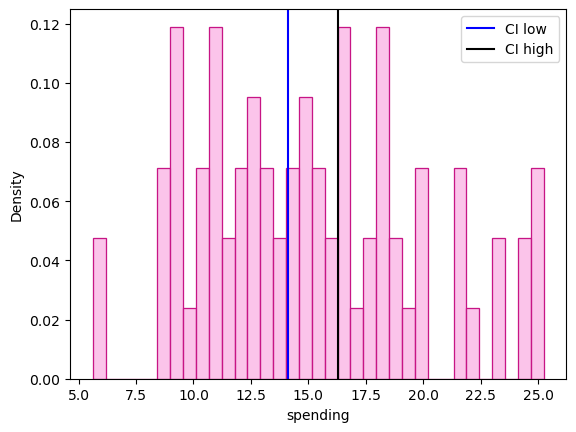

In [17]:
def confidence_interval(sample, alpha: float):
    """
    This function computes the z-score (1-alpha) confidence intervals for a given sample and significance level.

    Args:
        sample: The sample to calculate the confidence interval for.
        alpha: The significance level.

    Returns:
        The lower and upper bounds of the confidence interval.
    """
    n = len(sample)
    x = sample
    z_alpha_half = stats.norm.ppf(1 - alpha / 2) 
    
    x_bar = np.mean(x)
    sigma = np.std(x)

    ci_low = x_bar - z_alpha_half * sigma / np.sqrt(n)
    ci_high = x_bar + z_alpha_half * sigma / np.sqrt(n)
    return ci_low, ci_high
    
ci_low, ci_high = confidence_interval(sample1, 0.05)

alpha = 0.05
print(f"{(1-alpha):.0%} conv. interval: ({ci_low:.2f}, {ci_high:.2f})")

def plot_confidence_interval(sample, ci_low: float, ci_high: float) -> None:
    """
    This function generates a density plot of the sample and mark the lower and
    higher bounds of the confidence interval using vertical lines.

    Args:
        sample: The sample to plot.
        ci_low: The lower conf. interval of the sample.
        ci_high: The higher conf. interval of the sample.

    Returns:
        None.
    """
    plt.figure()
    sns.histplot(sample, bins = 35, stat='density',color=sns.color_palette("pastel")[6], edgecolor = "mediumvioletred")
    plt.axvline(ci_low, color = "blue", label = "CI low")
    plt.axvline(ci_high, color = "black", label = "CI high")
    plt.legend()
    plt.show()
    pass
plot_confidence_interval(sample1, ci_low, ci_high)

# Confidence intervals using z-score


In [18]:
def confidence_interval_tip(sample, alpha: float):
    """
    This function computes the z-score confidence interval for the true proportion of customers who leave a tip.

    Args:
        sample: The sample to calculate the confidence interval for (0 = no tip, 1 = tip).
        alpha: The significance level.

    Returns:
        The lower and upper bounds of the confidence interval.
    """

    n = len(sample)
    x = sample
    z_alpha_half = stats.norm.ppf(1 - alpha / 2) 
    p = np.mean(x)
    se = np.sqrt(p * (1-p) / n)

    ci_low = p - z_alpha_half * se 
    ci_high = p + z_alpha_half * se 
    return ci_low, ci_high

tip_sample = sampling(read_data(), 75, 12538316, "tip")

confidence_interval_tip(tip_sample, 0.05)

tip_ci_low, tip_ci_high = confidence_interval_tip(tip_sample, 0.05)
alpha = 0.05

print(f"{(1-alpha):.0%} conv. interval: ({tip_ci_low:.2f}, {tip_ci_high:.2f})")


95% conv. interval: (0.13, 0.32)


# Monte Carlo simulation


In [19]:
 def monte_carlo(data, b:int, n:int, spending_threshold:float, random_state:int) -> float:
    """
    Monte Carlo simulation to estimate the probability of reaching a spending_threshold.

    Args:
        data: The entire dataset of all 500 customers.
        b: Number of simulation steps.
        n: Number of samples per simulation step.
        spending_threshold: The threshold to calculate probability for.
        random_state: The random seed to use for reproducibility.

    Returns:
        Estimated probability of a customer of reaching the spending_threshold.
    """
    np.random.seed(random_state)
    mu = np.mean(data)
    sigma = np.std(data)
    x = 0

    for i in range(b):
        samples = stats.norm.rvs(loc = mu, scale = sigma, size = n)
        x += np.sum(samples > spending_threshold)
     
    total_samples = b * n 
    mc_probability = x / total_samples
    return mc_probability

entire_data = read_data().iloc[:,0]

b = 10000
n = 150
spending_threshold = 17

mc_prob = monte_carlo(entire_data, b, n, spending_threshold, 12538316)

print(f"Probability of a customer spending more than {spending_threshold}€: {mc_prob:.4f} ({mc_prob*100:.2f}%)")

Probability of a customer spending more than 17€: 0.3394 (33.94%)


# Bootstrapping


Bootstrap 95% conv. interval computed using 10000: (14.08, 16.26)


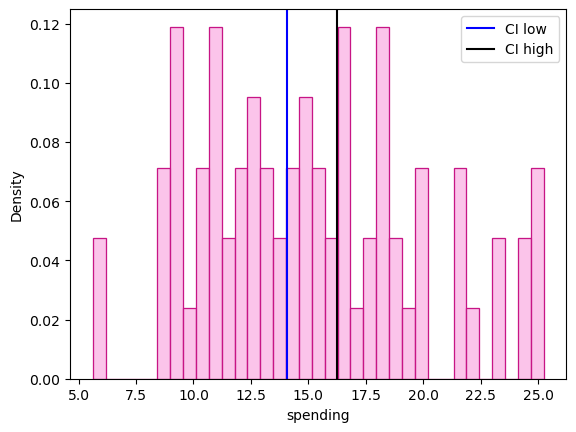

In [22]:
 def bootstrap(sample, bs_sample_size: int, alpha: float, random_state: int) -> tuple[float, float]:
    """
    This function computes the z-score confidence intervals for a given sample and confidence level.

    Args:
        sample: The sample to calculate the bootstrap confidence interval for.
        bs_sample_size: The bootstrap sample size.
        alpha: The significance level for the bootstrap interval.
        random_state: The random seed to use for reproducibility.

    Returns:
        The lower and upper bounds of the bootstrap confidence interval.
    """
    np.random.seed(random_state)
    n = len(sample)
    x = sample
    x_bar = np.mean(x)

    x_star = np.random.choice(x, (n, bs_sample_size), replace=True)
    x_star_bar = np.mean(x_star, axis=0)
    delta_star = x_star_bar - x_bar

    ci_low = x_bar - np.quantile(delta_star, 1 - alpha/2, method='linear')
    ci_high = x_bar - np.quantile(delta_star, alpha/2, method='linear')
    return ci_low, ci_high

bs_sample_size = 10000
alpha = 0.05

ci_low_bs, ci_high_bs = bootstrap(sample1, bs_sample_size, alpha, 12538316)

print(f"Bootstrap {(1-alpha):.0%} conv. interval computed using {bs_sample_size}: ({ci_low_bs:.2f}, {ci_high_bs:.2f})")

plot_confidence_interval(sample, ci_low_bs, ci_high_bs)

# Hypothesis testing (t-test)


T-test statistic: (2.723086361977752)
P-value: (0.01186094236846504)
We reject the null hypothesis. The observed result is too unlikely to happen if the null hypothesis were true.
In this case, the t-test statistic is indicating the sample mean is 2.723086361977752 standard errors above the hypothesized mean.


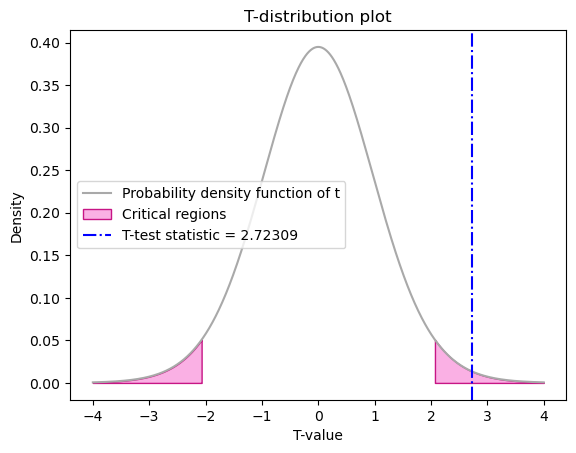

In [31]:
def hypothesis_test(sample, suspected_spending: float) -> tuple[float, float]:
    """
    This function computes a t-test and returns its statistic and p-value.

    Args:
        sample: The sample to test against.
        suspected_spending: The suspected spending to test against.

    Returns:
        The t-test statistic and p-value.
    """
    statistic, p_value = stats.ttest_1samp(sample, suspected_spending)
    print(f"T-test statistic: ({statistic})")
    print(f"P-value: ({p_value})")
    return statistic, p_value

new_sample = sampling(read_data(), 25, 12538316, "spending")
suspected_spending = 12

statistic, p_value = hypothesis_test(new_sample, suspected_spending)

if p_value < alpha:
    print("We reject the null hypothesis. The observed result is too unlikely to happen if the null hypothesis were true.")
    print(f"In this case, the t-test statistic is indicating the sample mean is {statistic} standard errors above the hypothesized mean.")
else:
    print("Insufficient evidence to reject null hypothesis.")
    print(f"In this case, the t-test statistic is indicating the sample mean is {statistic} standard errors above the hypothesized mean.")


def plot_hypothesis_test(suspected_spending: float, t_test_statistic: float, alpha: float) -> None:
    """
    This function plots the t-distibution, highlights the critical regions, and t-test statistic
    for the given suspected_spending.

    Args:
    - suspected_spending: The suspected spending to test against.
    - t_test_statistic: The t-test statistic.
    - alpha: The significance level.

    Returns:
        None.
    """
    sample_size = 25
    df = sample_size - 1  #this should be typically the df, but im not sure its correct

    x = np.linspace(-4, 4, 1000)

    y = stats.t.pdf(x, df)

    t_critical = stats.t.ppf(1 - alpha / 2, df)
    
    plt.figure()
    plt.plot(x, y, color="darkgrey", label="Probability density function of t")

    plt.fill_between(x, y, where=(x <= -t_critical), color=sns.color_palette("pastel")[6], edgecolor ="mediumvioletred")
    plt.fill_between(x, y, where=(x >= t_critical), color=sns.color_palette("pastel")[6], edgecolor ="mediumvioletred", label="Critical regions")

    plt.axvline(t_test_statistic, color="blue", linestyle="-.", label=f"T-test statistic = {t_test_statistic:.5f}")

    plt.title("T-distribution plot")
    plt.xlabel("T-value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    pass

plot_hypothesis_test(suspected_spending, statistic, alpha)

#We made the correct choice rejecting the null hypothesis since it falls inside the 'critical regions'.